In [ ]:
# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Impor library yang dibutuhkan
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- PERUBAHAN DI SINI ---
# Impor ResNet50 dan fungsi preprocessing-nya
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
# -------------------------

from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

Mounted at /content/drive


In [ ]:
# --- PASTIKAN PATH INI SESUAI DENGAN LOKASI FOLDER ANDA ---
train_dir = '/content/drive/MyDrive/Dataset_sampah/Training'
validation_dir = '/content/drive/MyDrive/Dataset_sampah/Validation'
# ---------------------------------------------------------

# Tentukan parameter untuk gambar dan batch
IMG_SIZE = (224, 224) # Ukuran gambar standar untuk ResNet50
BATCH_SIZE = 32

# Gunakan ImageDataGenerator untuk memuat data dan melakukan augmentasi
train_datagen = ImageDataGenerator(
    # --- PERUBAHAN DI SINI ---
    preprocessing_function=preprocess_input, # Gunakan preprocessing khusus ResNet50
    # -------------------------
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    # --- PERUBAHAN DI SINI ---
    preprocessing_function=preprocess_input
    # -------------------------
)

# Buat generator data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 1194 images belonging to 2 classes.
Found 276 images belonging to 2 classes.


In [ ]:
# 1. Muat model dasar ResNet50
# `include_top=False` berarti kita tidak menyertakan lapisan output asli dari model
base_model = ResNet50( # <-- PERUBAHAN DI SINI
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Bekukan (freeze) lapisan-lapisan di model dasar
base_model.trainable = False

# 3. Tambahkan lapisan klasifikasi kita sendiri di atas model dasar (SAMA SEPERTI SEBELUMNYA)
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x) # Meratakan output menjadi vektor
x = Dropout(0.2)(x) # Tambahkan dropout untuk regularisasi
outputs = Dense(1, activation='sigmoid')(x) # Lapisan output untuk 2 kelas

# 4. Gabungkan menjadi model akhir
model = Model(inputs, outputs)

# Tampilkan ringkasan model
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Kompilasi model dengan optimizer, loss function, dan metrik
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Tentukan jumlah epoch
EPOCHS = 5

# Mulai proses training
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 914s 24s/step - accuracy: 0.6406 - loss: 0.6521 - val_accuracy: 0.8551 - val_loss: 0.3993
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 448s 12s/step - accuracy: 0.8123 - loss: 0.4323 - val_accuracy: 0.9348 - val_loss: 0.2719
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 457s 12s/step - accuracy: 0.9024 - loss: 0.2998 - val_accuracy: 0.9529 - val_loss: 0.1999
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 517s 14s/step - accuracy: 0.9303 - loss: 0.2365 - val_accuracy: 0.9710 - val_loss: 0.1570
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 446s 12s/step - accuracy: 0.9437 - loss: 0.2041 - val_accuracy: 0.9746 - val_loss: 0.1273


9/9 ━━━━━━━━━━━━━━━━━━━━ 86s 9s/step
Classification Report
              precision    recall  f1-score   support

   Anorganik       0.96      0.99      0.98       139
     Organik       0.99      0.96      0.97       137

    accuracy                           0.97       276
   macro avg       0.97      0.97      0.97       276
weighted avg       0.97      0.97      0.97       276

Confusion Matrix


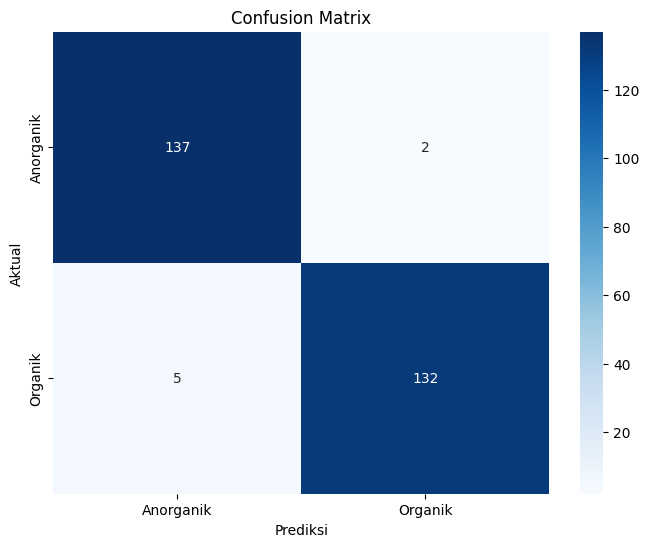

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Membuat prediksi pada seluruh data validasi
# Pastikan validation_generator di-reset dan tidak di-shuffle
validation_generator.reset()
Y_pred = model.predict(validation_generator, steps=validation_generator.samples // BATCH_SIZE + 1)
y_pred = (Y_pred > 0.5).astype(int) # Konversi probabilitas menjadi kelas biner (0 atau 1)

# 2. Mendapatkan label yang sebenarnya
y_true = validation_generator.classes

# 3. Menampilkan Classification Report (Akurasi, Presisi, Recall, F1-Score)
print("Classification Report")
# Urutan kelas: 'anorganik' (kelas 0), 'organik' (kelas 1)
target_names = list(validation_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Menampilkan Confusion Matrix
print("Confusion Matrix")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


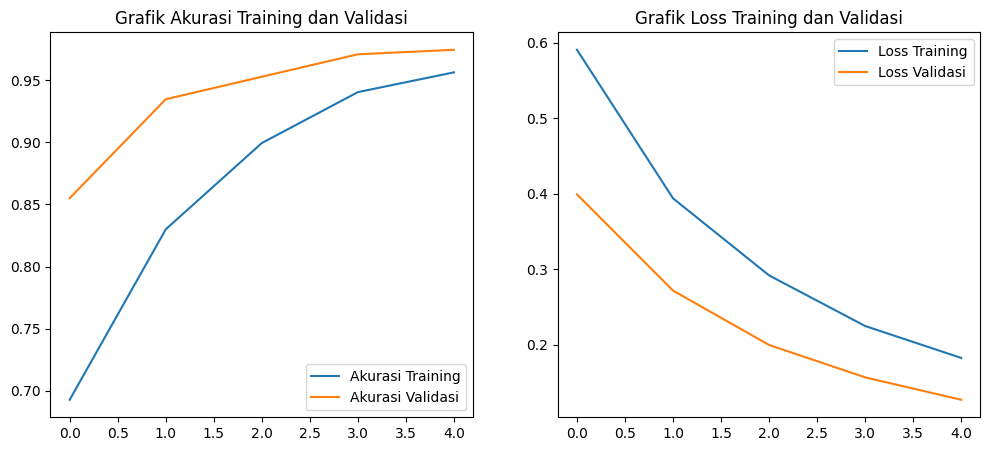

In [ ]:
# Ambil hasil dari history training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

# Buat plot untuk akurasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Training')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi')
plt.legend(loc='lower right')
plt.title('Grafik Akurasi Training dan Validasi')

# Buat plot untuk loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Training')
plt.plot(epochs_range, val_loss, label='Loss Validasi')
plt.legend(loc='upper right')
plt.title('Grafik Loss Training dan Validasi')
plt.show()

Saving download (17).jpeg to download (17) (1).jpeg


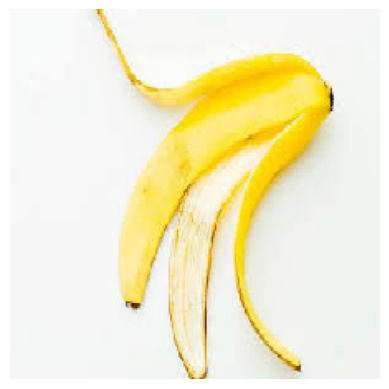

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
File: download (17) (1).jpeg
Prediksi: Sampah Organik


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
# Upload gambar baru
uploaded = files.upload()

for fn in uploaded.keys():
  # Memuat dan mempersiapkan gambar
  path = fn
  img = image.load_img(path, target_size=(224, 224))
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

  # Konversi gambar ke array dan lakukan preprocessing
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  # --- PERUBAHAN DI SINI ---
  x = preprocess_input(x) # Gunakan preprocessing ResNet50
  # -------------------------

  # Lakukan prediksi
  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)

  print(f"File: {fn}")

  # Cek hasil prediksi
  # Urutan kelas: 'anorganik' (kelas 0), 'organik' (kelas 1)
  if classes[0] < 0.5:
    print('Prediksi: Sampah Anorganik')
  else:
    print('Prediksi: Sampah Organik')

In [ ]:
model.save('model_sampah_mobilenetv2.h5')